In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 4 seconds. 122 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [61]:
d = 10
nsamples = 1000
T = 50

50

In [87]:
M = randn(d,d) * 0.5
J = M * M'

10×10 Matrix{Float64}:
  2.70241    1.05835    -0.546106   …  -0.963579  -0.194373    0.242832
  1.05835    1.94054     0.0282932     -0.920116   0.090502    0.805485
 -0.546106   0.0282932   1.95816       -0.371849   1.07993     0.458622
 -1.16376   -1.10396    -0.225096       1.4509    -0.744511    1.12486
 -0.122564   0.696456    1.17165       -0.310285   0.341686    1.51118
 -0.200384   0.130502    0.765283   …   0.274284   0.0589472   0.798096
  0.793425   0.534419    0.443668      -0.948088   1.1615     -0.123961
 -0.963579  -0.920116   -0.371849       1.42246   -0.268461   -0.42341
 -0.194373   0.090502    1.07993       -0.268461   1.47582    -0.531694
  0.242832   0.805485    0.458622      -0.42341   -0.531694    3.13941

In [88]:
eigen(inv(J))

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
10-element Vector{Float64}:
  0.14530227822903832
  0.1667407671525904
  0.1921652279462661
  0.26240529065540835
  0.6522752777757266
  1.0731557667454819
  1.7356801037379272
  2.3163753255233894
  2.528236335093224
 12.391581111660484
vectors:
10×10 Matrix{Float64}:
 -0.375524    0.131924   -0.0961623   …   0.0293262  -0.0353842   0.0353595
 -0.27614     0.306329    0.0192446       0.331544    0.249488   -0.0356246
 -0.0339067   0.282224    0.196226        0.262401    0.447193   -0.341311
  0.463327   -0.267699    0.593669        0.174251    0.284864    0.35965
  0.0347858   0.448613    0.249074       -0.716884   -0.081205    0.255629
  0.297274    0.499144   -0.14364     …   0.0095931   0.0759612  -0.0698932
 -0.545615   -0.22344     0.566441       -0.20873    -0.0213915  -0.294188
  0.345384   -0.195593    0.00108161     -0.0299638  -0.425531   -0.586388
 -0.204075    0.0545248   0.0785994       0.413454   -0.54125 

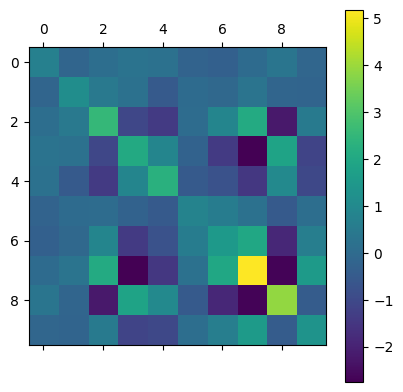

PyObject <matplotlib.colorbar.Colorbar object at 0x74febdb34700>

In [89]:
matshow(inv(J))
colorbar()

In [90]:
θ0 = zeros(d)
θ1 = randn(d)
θ = θ0 .+ (θ1 .* randn(d))
θ |> norm

3.6807999340596904

In [91]:
γ = 0.1

0.1

In [92]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

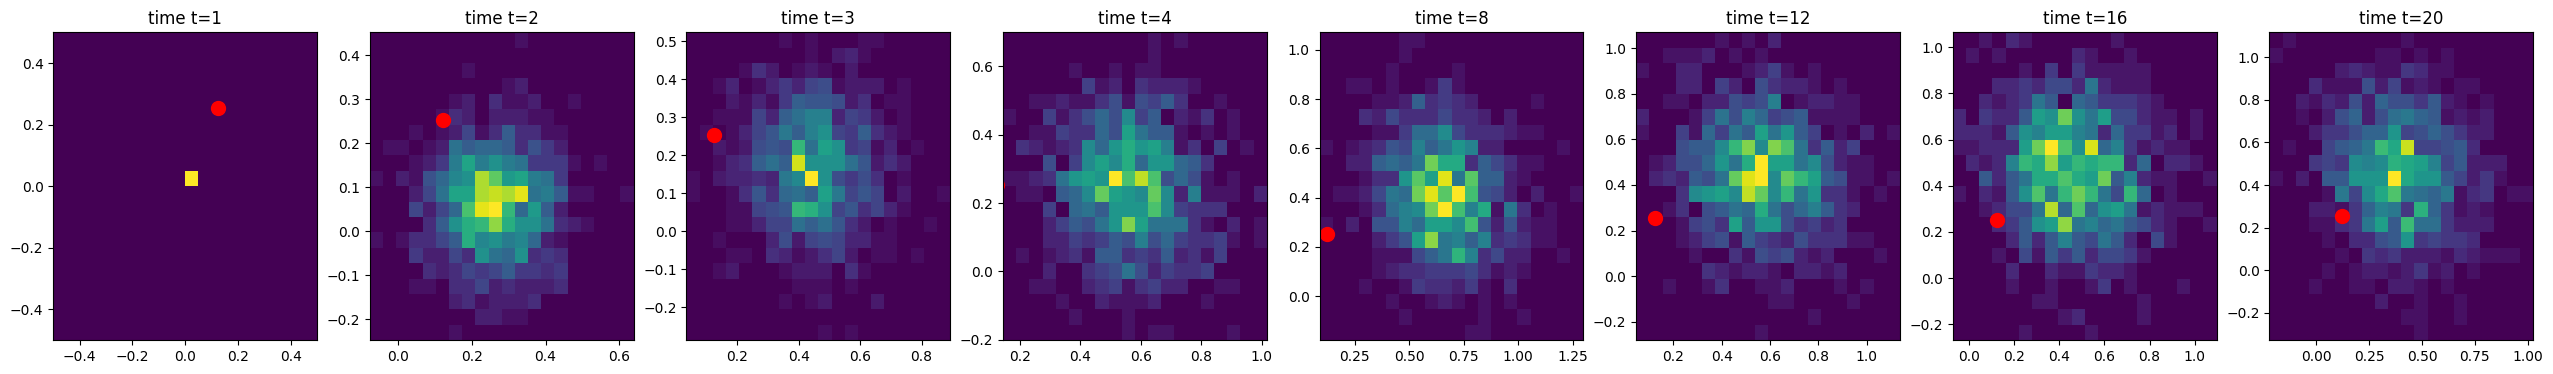

In [93]:
tpoints = [1,2,3,4,8,12,16,20]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red", s=100)
    ax[t].set_title("time t=$(tpoints[t])")
end

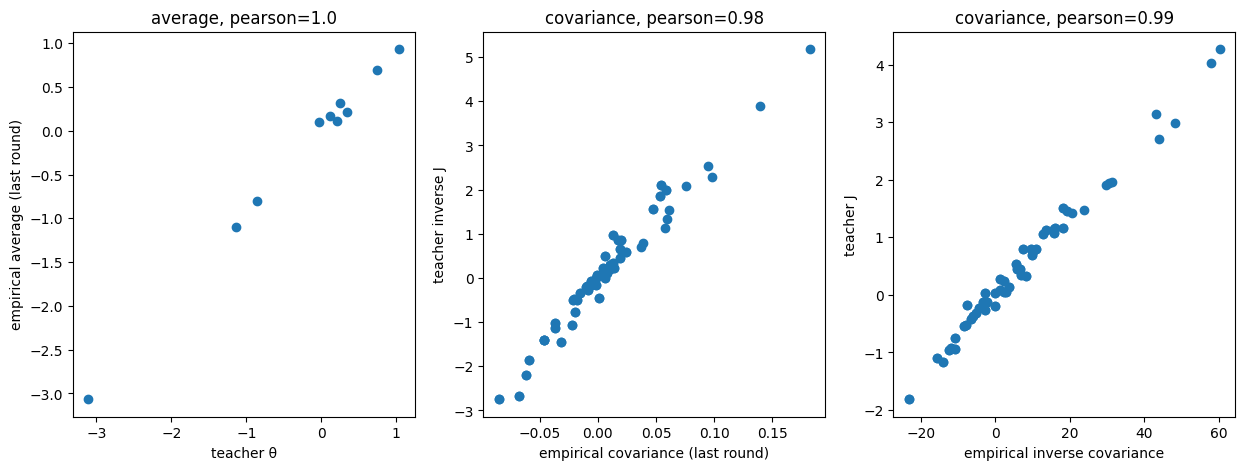

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [94]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [95]:
counts = ones(nsamples, T) ./ nsamples
deltas = fill(1,T)
data = collect_data(x, counts, deltas);

In [99]:
l_values, x_opt, status = learn_gamma_nlopt(data, initialize=T, λ=0.0, prior=0.0, ftol_rel=1e-7)

(-34.838439151887115, [43.913433419690875, 12.846282363513321, 30.37450649322608, -8.557749859734763, -0.10524040879747769, 31.361204139112605, -14.09561586613072, -15.80482224515451, -4.493623749318847, 57.85565939365955  …  0.35485411182677645, -3.0693618868885935, 0.12475692535065663, -0.850588523642116, 0.7396013866421529, 0.15819650541698235, 0.2033690150775078, -1.1682798625982709, 0.9146680516842284, 0.0070377744830656215], :FTOL_REACHED)

In [100]:
J_inferred = de.compute_J(x_opt, data.d);

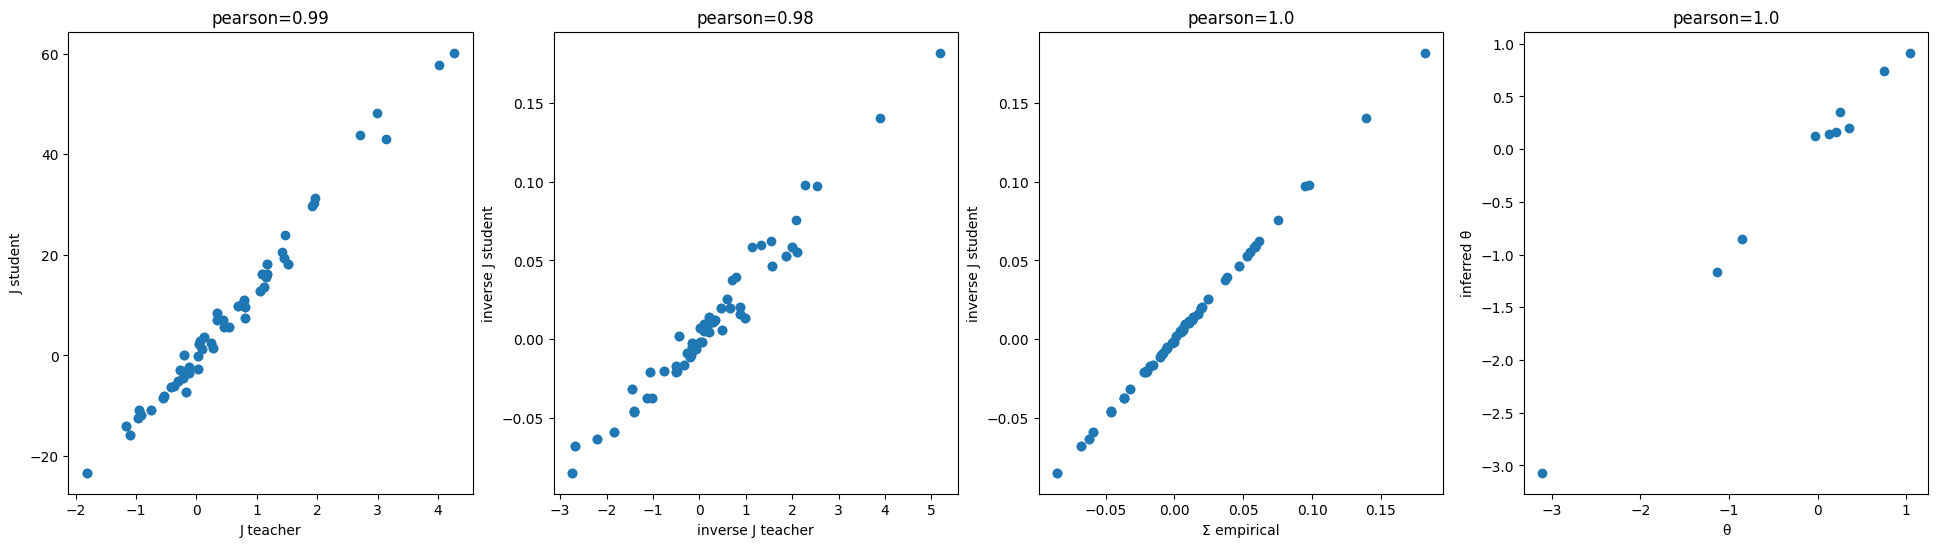

PyObject Text(0.5, 1.0, 'pearson=1.0')

In [101]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
rho_theta = cor(vec(θ), x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")